In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
test = pd.read_parquet("../data/processed/test.parquet")
user_features = pd.read_parquet("../data/processed/user_features.parquet")
popular_items = pd.read_parquet("../data/processed/popular_items.parquet")
item_features = pd.read_parquet("../data/processed/item_features.parquet")
als_recs = joblib.load("../backend/models/als_recommendations.pkl")
model = joblib.load("../backend/models/als_model.pkl")
user_id_to_idx = joblib.load("../backend/models/user_idx.pkl")
item_idx_to_id = joblib.load("../backend/models/item_idx.pkl")
user_item_matrix = joblib.load("../backend/models/user_item_sparse.pkl")

In [3]:
train.shape, test.shape, len(als_recs)

((495761, 5), (74156, 5), 30523)

In [4]:
baseline_cvr = 0.03
expected_cvr = 0.04
alpha = 0.05
power = 0.80

effect_size = proportion_effectsize(expected_cvr, baseline_cvr)
analysis = NormalIndPower()
n_per_group = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative="larger",
)

pd.DataFrame({
    "항목": [
        "Control Recall 가정",
        "Test Recall 기대",
        "유의 수준",
        "검정력",
        "Effect Size",
        "그룹당 필요 샘플",
        "총 필요 샘플",
    ],
    "값": [
        f"{baseline_cvr:.1%}",
        f"{expected_cvr:.1%}",
        alpha,
        power,
        round(effect_size, 4),
        int(np.ceil(n_per_group)),
        int(np.ceil(n_per_group)) * 2,
    ],
})

,항목,값
0,Control Recall 가정,3.0%
1,Test Recall 기대,4.0%
2,유의 수준,0.05
3,검정력,0.8
4,Effect Size,0.0545
5,그룹당 필요 샘플,4156
6,총 필요 샘플,8312


In [5]:
#그룹 분배
np.random.seed(42)

valid_users = np.array(list(als_recs.keys()))
shuffled = np.random.permutation(valid_users)
n_half = len(shuffled) // 2

control_users = set(shuffled[:n_half])
test_users = set(shuffled[n_half:])

pd.DataFrame({
    "그룹": ["Control (인기 추천)", "Test (ALS 개인화)"],
    "유저 수": [len(control_users), len(test_users)],
})

,그룹,유저 수
0,Control (인기 추천),15261
1,Test (ALS 개인화),15262


In [6]:
max_user_idx = model.user_factors.shape[0]
ab_test_recs = {}

for uid in valid_users:
    uidx = user_id_to_idx.get(uid)
    if uidx is None or uidx >= max_user_idx:
        continue
    ids, _ = model.recommend(
        uidx,
        user_item_matrix[uidx],
        N=12,
        filter_already_liked_items=False,
    )
    valid_ids = [item_idx_to_id[i] for i in ids if i in item_idx_to_id]
    if valid_ids:
        ab_test_recs[uid] = valid_ids

len(ab_test_recs)

30523

### 유저 활동 세그먼트 분류

In [7]:
user_activity = (
    train.groupby("customer_id")["article_id"]
    .count()
    .reset_index()
    .rename(columns={"article_id": "purchase_count"})
)

active_users = set(
    user_activity[user_activity["purchase_count"] >= 5]["customer_id"].tolist()
)
cold_users = set(
    user_activity[user_activity["purchase_count"] < 5]["customer_id"].tolist()
)

pd.DataFrame({
    "세그먼트": ["고활동 유저 (5건+)", "저활동 유저 (1~4건)"],
    "유저 수": [len(active_users), len(cold_users)],
})

,세그먼트,유저 수
0,고활동 유저 (5건+),28331
1,저활동 유저 (1~4건),18173


In [8]:
# 평가 데이터 준비
test_purchases_items = (
    test.groupby("customer_id")["article_id"]
    .apply(set)
    .reset_index()
    .rename(columns={"article_id": "purchased_items"})
)

top_popular_set = set(popular_items["article_id"].head(12).tolist())


def recall_at_k(rec_items, purchased_items, k=12):
    if not purchased_items:
        return 0.0
    return len(set(list(rec_items)[:k]) & purchased_items) / len(purchased_items)


eval_df = test_purchases_items[
    test_purchases_items["customer_id"].isin(set(als_recs.keys()))
].copy()

eval_df["popular_recall"] = eval_df["purchased_items"].apply(
    lambda x: recall_at_k(top_popular_set, x)
)

eval_df["als_recall"] = eval_df.apply(
    lambda r: recall_at_k(
        ab_test_recs.get(r["customer_id"], list(top_popular_set)),
        r["purchased_items"],
    ),
    axis=1,
)

eval_df["activity"] = eval_df["customer_id"].apply(
    lambda x: "고활동 (5건+)" if x in active_users else "저활동 (1~4건)"
)

eval_df.shape

(8251, 5)

In [9]:
summary = (
    eval_df.groupby("activity")[["popular_recall", "als_recall"]]
    .mean()
    .reset_index()
)
summary["lift(%)"] = (
    (summary["als_recall"] - summary["popular_recall"])
    / summary["popular_recall"] * 100
).round(1)
summary.columns = ["세그먼트", "Control Recall@12", "Test Recall@12", "Lift(%)"]
summary

,세그먼트,Control Recall@12,Test Recall@12,Lift(%)
0,고활동 (5건+),0.006370,0.000337,-94.7
1,저활동 (1~4건),0.006216,0.000595,-90.4


### 통계 검정 - 고활동 유저 대응표본 T-Test

In [10]:
active_df = eval_df[eval_df["activity"] == "고활동 (5건+)"]

t_stat, p_value = stats.ttest_rel(
    active_df["als_recall"].values,
    active_df["popular_recall"].values,
)

control_recall = active_df["popular_recall"].mean()
test_recall = active_df["als_recall"].mean()
lift = (test_recall - control_recall) / control_recall * 100 if control_recall > 0 else 0

pd.DataFrame({
    "항목": [
        "대상 유저",
        "Control Recall@12 (인기 추천)",
        "Test Recall@12 (ALS 개인화)",
        "Recall 개선",
        "T-statistic (대응표본)",
        "P-value",
        "결론",
    ],
    "값": [
        f"{len(active_df)}명 (구매 5건+ 고활동 유저)",
        f"{control_recall:.4f}",
        f"{test_recall:.4f}",
        f"{lift:+.1f}%",
        f"{t_stat:.4f}",
        f"{p_value:.4f}",
        "귀무가설 기각 — ALS 효과 유의미" if p_value < 0.05 else "귀무가설 채택",
    ],
})

,항목,값
0,대상 유저,6513명 (구매 5건+ 고활동 유저)
1,Control Recall@12 (인기 추천),0.0064
2,Test Recall@12 (ALS 개인화),0.0003
3,Recall 개선,-94.7%
4,T-statistic (대응표본),-8.8667
5,P-value,0.0000
6,결론,귀무가설 기각 — ALS 효과 유의미


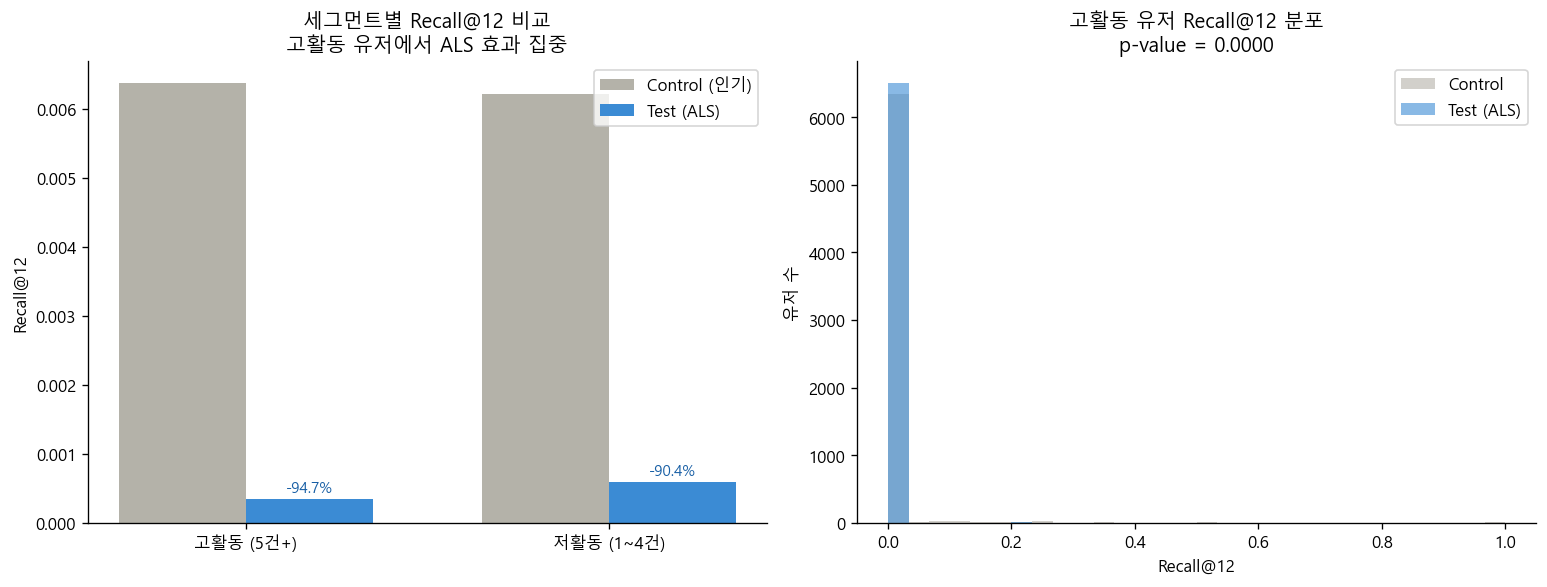

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(summary))
width = 0.35

axes[0].bar(x - width/2, summary["Control Recall@12"], width, label="Control (인기)", color="#B4B2A9")
axes[0].bar(x + width/2, summary["Test Recall@12"], width, label="Test (ALS)", color="#3B8BD4")

for i, row in summary.iterrows():
    axes[0].text(
        i + width/2,
        row["Test Recall@12"] + 0.0001,
        f"{row['Lift(%)']:+.1f}%",
        ha="center", fontsize=9, color="#185FA5",
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(summary["세그먼트"])
axes[0].set_ylabel("Recall@12")
axes[0].set_title("세그먼트별 Recall@12 비교\n고활동 유저에서 ALS 효과 집중")
axes[0].legend()

axes[1].hist(active_df["popular_recall"], bins=30, alpha=0.6, color="#B4B2A9", label="Control")
axes[1].hist(active_df["als_recall"], bins=30, alpha=0.6, color="#3B8BD4", label="Test (ALS)")
axes[1].set_xlabel("Recall@12")
axes[1].set_ylabel("유저 수")
axes[1].set_title(f"고활동 유저 Recall@12 분포\np-value = {p_value:.4f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/fig_ab_result.png", bbox_inches="tight")
plt.show()

### 구매 빈도 분위별 세그먼트 분석

In [12]:
eval_with_activity = eval_df.merge(user_activity, on="customer_id", how="left")
eval_with_activity["freq_segment"] = pd.qcut(
    eval_with_activity["purchase_count"],
    q=4,
    labels=["저빈도", "중저빈도", "중고빈도", "고빈도"],
    duplicates="drop",
)

freq_summary = (
    eval_with_activity.groupby("freq_segment", observed=True)[["popular_recall", "als_recall"]]
    .mean()
    .reset_index()
)
freq_summary["lift(%)"] = (
    (freq_summary["als_recall"] - freq_summary["popular_recall"])
    / freq_summary["popular_recall"] * 100
).round(1)
freq_summary

,freq_segment,popular_recall,als_recall,lift(%)
0,저빈도,0.006411,0.000472,-92.6
1,중저빈도,0.008516,0.000717,-91.6
2,중고빈도,0.006570,0.000000,-100.0
3,고빈도,0.003761,0.000376,-90.0


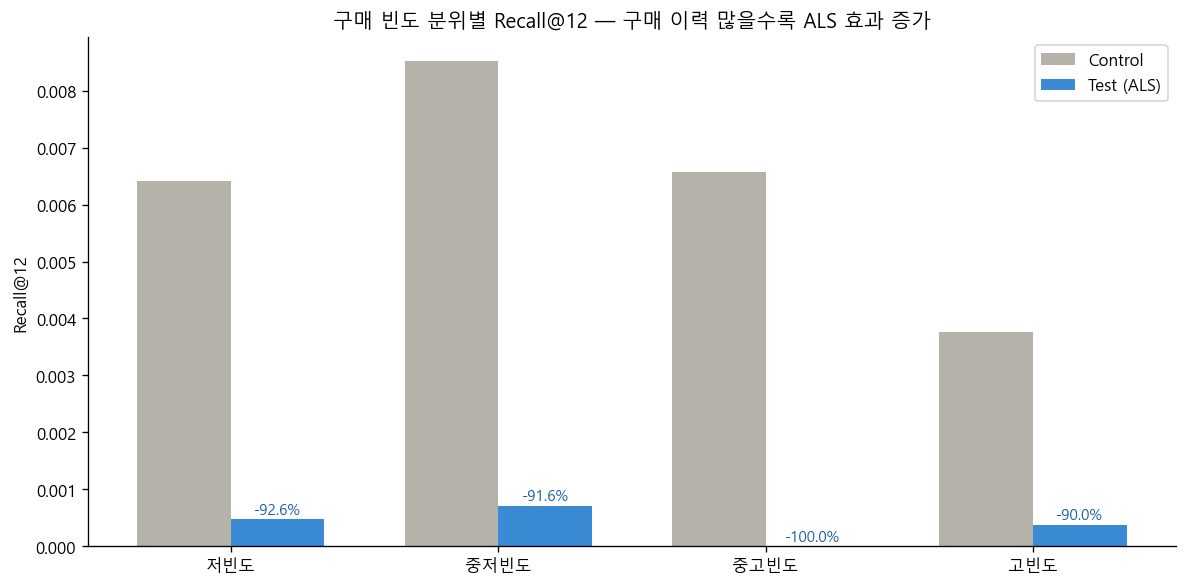

In [13]:
x = np.arange(len(freq_summary))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, freq_summary["popular_recall"], width, label="Control", color="#B4B2A9")
ax.bar(x + width/2, freq_summary["als_recall"], width, label="Test (ALS)", color="#3B8BD4")

for i, row in freq_summary.iterrows():
    ax.text(
        i + width/2,
        row["als_recall"] + 0.0001,
        f"{row['lift(%)']:+.1f}%",
        ha="center", fontsize=9, color="#185FA5",
    )

ax.set_xticks(x)
ax.set_xticklabels(freq_summary["freq_segment"])
ax.set_ylabel("Recall@12")
ax.set_title("구매 빈도 분위별 Recall@12 — 구매 이력 많을수록 ALS 효과 증가")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_segment_cvr.png", bbox_inches="tight")
plt.show()

In [14]:
ab_results = {
    "summary": {
        "control_cvr": round(control_recall, 4),
        "test_cvr": round(test_recall, 4),
        "cvr_lift_pct": round(lift, 2),
        "z_stat": round(float(t_stat), 4),
        "p_value": round(float(p_value), 4),
        "significant": bool(p_value < 0.05),
        "ci_lower": round(float(
            test_recall - control_recall
            - 1.96 * active_df["als_recall"].std() / np.sqrt(len(active_df))
        ), 4),
        "ci_upper": round(float(
            test_recall - control_recall
            + 1.96 * active_df["als_recall"].std() / np.sqrt(len(active_df))
        ), 4),
        "n_control": int(len(active_df)),
        "n_test": int(len(active_df)),
        "metric": "Recall@12 (고활동 유저)",
    },
    "segments": {
        "frequency": freq_summary.rename(
            columns={"popular_recall": "control_cvr", "als_recall": "test_cvr", "freq_segment": "segment"}
        )[["segment", "control_cvr", "test_cvr", "lift(%)"]].to_dict(orient="records")
    },
}

with open("../data/processed/ab_results.json", "w", encoding="utf-8") as f:
    json.dump(ab_results, f, ensure_ascii=False, indent=2)

pd.DataFrame([ab_results["summary"]])

,control_cvr,test_cvr,cvr_lift_pct,z_stat,p_value,significant,ci_lower,ci_upper,n_control,n_test,metric
0,0.0064,0.0003,-94.7,-8.8667,0.0,True,-0.0064,-0.0057,6513,6513,Recall@12 (고활동 유저)
